In [6]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

BASE = Path(".")

q1 = {
    "Expert1": [4,4,4,4,4,3,4,3,3,4,], # 0322
    "Expert2": [5,3,5,4,4,3,3,4,4,5,], # A
    "Expert3": [5,5,5,3,5,2,3,5,5,5,], # U
    "Expert4": [4,4,4,4,4,4,4,4,4,4,], # S
}
q2 = {
    "Expert1": [4,4,3,4,3,4,4,4,3,4,], # 0322
    "Expert2": [5,3,4,3,4,3,3,3,4,4,], # A
    "Expert3": [4,4,4,4,4,4,4,4,4,4,], # U
    "Expert4": [5,4,4,3,4,4,4,4,3,4,], # S
}
# q3 = {
#     "Expert1": [4,3,4,3,4,3,3,4,4,4,], # 0322
#     "Expert2": [5,2,3,2,5,2,3,3,3,3,], # A
#     "Expert3": [4,4,4,3,4,5,4,4,4,3,], # U
#     "Expert4": [4,5,3,3,4,4,4,3,3,3,], # S
# }

questions = {
    "Q1: How easy is it to understand the\nconditions described by this rule?": q1,
    "Q2: Does this rule help you narrow down which types of\nconditions to prioritize for testing the updated system?": q2,
#     "Q3: Does this rule point you toward a specific\narea of the system to investigate further?": q3
}

x_axis_labels = {
    "Q1: How easy is it to understand the\nconditions described by this rule?": [
        "1\nVery Difficult",
        "2\nDifficult",
        "3\nModerately Easy",
        "4\nEasy",
        "5\nVery Easy",
    ],
    "Q2: Does this rule help you narrow down which types of\nconditions to prioritize for testing the updated system?": [
        "1\nNot at all",
        "2\nSlightly",
        "3\nModerately",
        "4\nConsiderably",
        "5\nVery much",
    ],
}

experts = ["Expert1", "Expert2", "Expert3", "Expert4"]
values = [1, 2, 3, 4, 5]

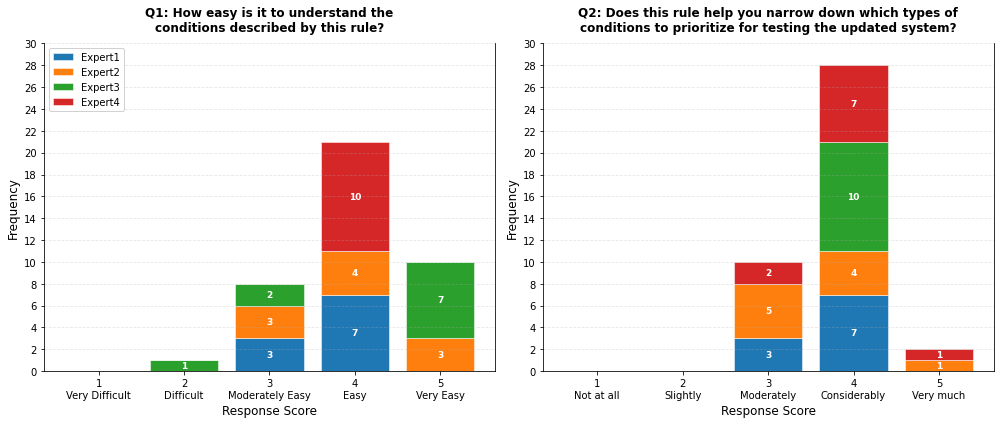

Average score for Q1: 4.00
Average score for Q2: 3.80


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (q_name, q_data) in enumerate(questions.items()):
    ax = axes[idx]
    x = np.arange(len(values))
    bottom = np.zeros(len(values))

    for expert in experts:
        counts = np.array([q_data[expert].count(v) for v in values])

        bars = ax.bar(
            x,
            counts,
            bottom=bottom,
            label=expert,
            edgecolor="white",
            linewidth=0.5
        )

        for i, (bar, c) in enumerate(zip(bars, counts)):
            if c > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + c / 2,
                    str(c),
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white"
                )

        bottom += counts

    ax.set_title(q_name, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Response Score", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_axis_labels[q_name], fontsize=10)
    ax.set_ylim(0, 30)
    ax.set_yticks(range(0, 32, 2))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

axes[0].legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

fig.savefig(BASE / "expert_assessment.pdf")
fig.savefig(BASE / "expert_assessment.png", dpi=600)

print(f"Average score for Q1: {np.mean([np.mean(v) for v in q1.values()]):.2f}")
print(f"Average score for Q2: {np.mean([np.mean(v) for v in q2.values()]):.2f}")
# print(f"Average score for Q3: {np.mean([np.mean(v) for v in q3.values()])}")

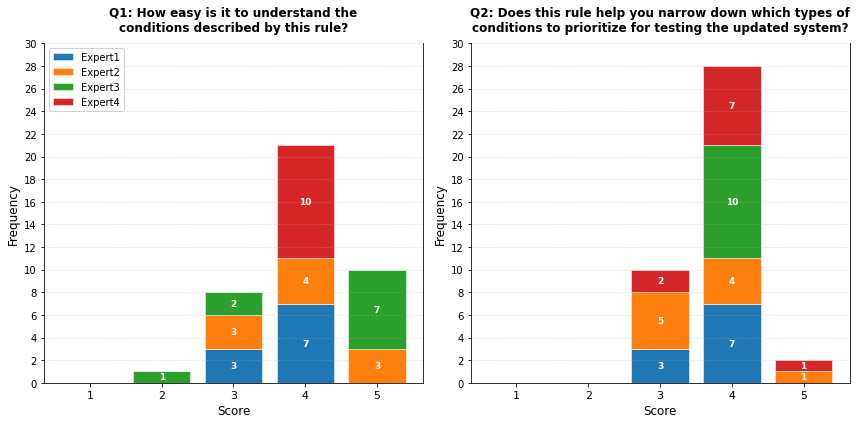

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for idx, (q_name, q_data) in enumerate(questions.items()):
    ax = axes[idx]
    x = np.arange(len(values))

    bottom = np.zeros(len(values))  # stacking baseline

    for expert in experts:
        counts = np.array([q_data[expert].count(v) for v in values])

        bars = ax.bar(
            x,
            counts,
            bottom=bottom,
            label=expert,
            edgecolor="white",
            linewidth=0.5
        )

        # annotate each segment
        for i, (bar, c) in enumerate(zip(bars, counts)):
            if c > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom[i] + c/2,   # center inside stack
                    str(c),
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white"
                )

        bottom += counts  # update stacking

    ax.set_title(q_name, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(values, fontsize=11)
    ax.set_ylim(0, 30)
    ax.set_yticks(range(0, 32, 2))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

axes[0].legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

fig.savefig(BASE / "expert_assessment.pdf")
fig.savefig(BASE / "expert_assessment.png", dpi=600)


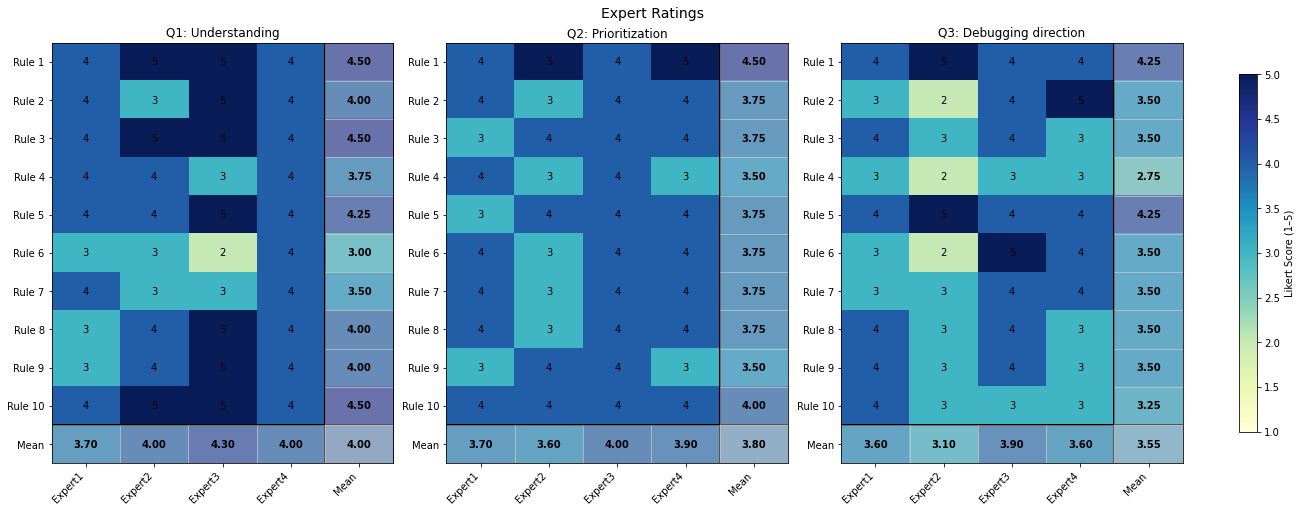

In [4]:
from matplotlib import pyplot as plt
import numpy as np

def plot_heatmap_with_means(ax, title, qdata, experts, rule_labels):
    data = np.array([qdata[e] for e in experts]).T  # (10,4)

    # Means
    row_means = data.mean(axis=1, keepdims=True)
    col_means = data.mean(axis=0, keepdims=True)
    overall_mean = data.mean()

    top = np.hstack([data, row_means])
    bottom = np.hstack([col_means, [[overall_mean]]])
    full = np.vstack([top, bottom])

    x_labels = experts + ["Mean"]
    y_labels = rule_labels + ["Mean"]

    im = ax.imshow(full, cmap="YlGnBu", vmin=1, vmax=5, aspect="auto")

    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels)

    # === Draw separator lines ===
    ax.axhline(len(rule_labels)-0.5, color="black", linewidth=2)
    ax.axvline(len(experts)-0.5, color="black", linewidth=2)

    # === Annotate cells ===
    for i in range(full.shape[0]):
        for j in range(full.shape[1]):
            val = full[i, j]

            is_mean_cell = (i == full.shape[0]-1) or (j == full.shape[1]-1)

            if is_mean_cell:
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="black"
                )
            else:
                ax.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=10
                )

    # === Highlight mean row/column with overlay ===
    # (semi-transparent gray layer)
    for j in range(full.shape[1]):
        ax.add_patch(plt.Rectangle(
            (j-0.5, len(rule_labels)-0.5),
            1, 1,
            fill=True, color="lightgray", alpha=0.4, zorder=2
        ))

    for i in range(full.shape[0]):
        ax.add_patch(plt.Rectangle(
            (len(experts)-0.5, i-0.5),
            1, 1,
            fill=True, color="lightgray", alpha=0.4, zorder=2
        ))

    return im

questions = {
    "Q1: Understanding": q1,
    "Q2: Prioritization": q2,
    "Q3: Debugging direction": q3,
}

rule_labels = [f"Rule {i}" for i in range(1, 11)]

# ===================== PLOT =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

for ax, (title, qdata) in zip(axes, questions.items()):
    im = plot_heatmap_with_means(ax, title, qdata, experts, rule_labels)

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Likert Score (1–5)")

fig.suptitle("Expert Ratings", fontsize=14)

fig.savefig(BASE / "heatmap.pdf")
fig.savefig(BASE / "heatmap.png", dpi=600)

plt.show()

# Comparison of backgrounds

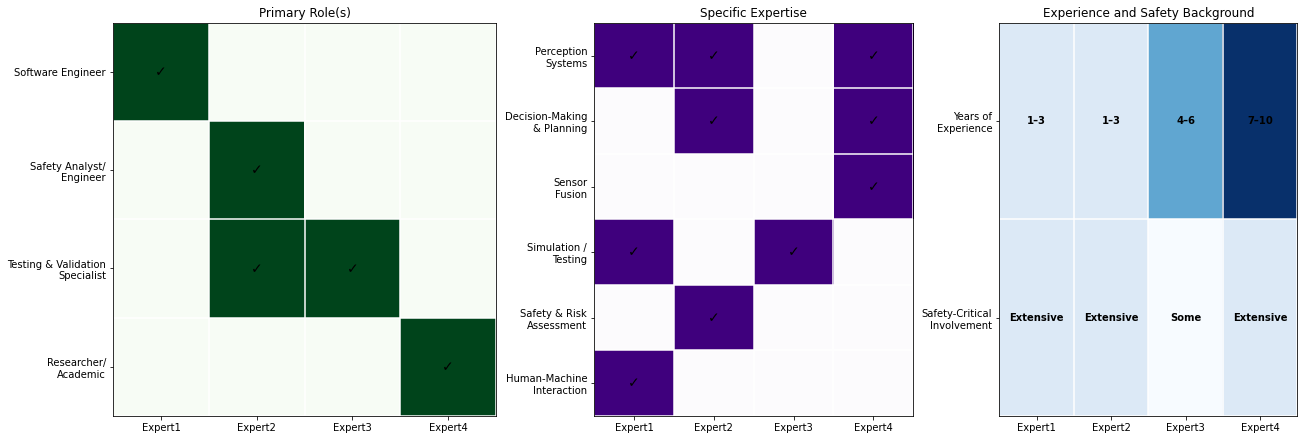

In [5]:
from matplotlib import pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Expert mapping from your study:
# Expert1 = 0322
# Expert2 = A
# Expert3 = U
# Expert4 = S
# ------------------------------------------------------------------

experts = ["Expert1", "Expert2", "Expert3", "Expert4"]

# -----------------------------
# 1) Primary role(s)
# -----------------------------
role_categories = [
    "Software Engineer",
    "Safety Analyst/\nEngineer",
    "Testing & Validation\nSpecialist",
    "Researcher/\nAcademic",
]

role_matrix = np.array([
    [1, 0, 0, 0],  # Expert1
    [0, 1, 1, 0],  # Expert2
    [0, 0, 1, 0],  # Expert3
    [0, 0, 0, 1],  # Expert4
]).T  # rows=roles, cols=experts

# -----------------------------
# 2) Specific expertise
# -----------------------------
expertise_categories = [
    "Perception\nSystems",
    "Decision-Making\n& Planning",
    "Sensor\nFusion",
    "Simulation /\nTesting",
    "Safety & Risk\nAssessment",
    "Human-Machine\nInteraction",
]

expertise_matrix = np.array([
    [1, 0, 0, 1, 0, 1],  # Expert1
    [1, 1, 0, 0, 1, 0],  # Expert2
    [0, 0, 0, 1, 0, 0],  # Expert3
    [1, 1, 1, 0, 0, 0],  # Expert4
]).T  # rows=expertise, cols=experts

# -----------------------------
# 3) Experience + safety involvement
# Encode years as ordinal midpoints
# 1–3 -> 2, 4–6 -> 5, 7–10 -> 8.5
# Safety: extensive=2, some extent=1, no=0
# -----------------------------
summary_categories = [
    "Years of\nExperience",
    "Safety-Critical\nInvolvement",
]

summary_matrix = np.array([
    [2.0, 2.0, 5.0, 8.5],  # years
    [2.0, 2.0, 1.0, 2.0],  # safety involvement
])

# Labels shown inside cells
summary_labels = np.array([
    ["1–3", "1–3", "4–6", "7–10"],
    ["Extensive", "Extensive", "Some", "Extensive"],
])

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    gridspec_kw={"width_ratios": [1.8, 1.5, 1.4]},
    constrained_layout=True
)

# -------- Roles panel --------
ax = axes[0]
im1 = ax.imshow(role_matrix, cmap="Greens", vmin=0, vmax=1, aspect="auto")
ax.set_title("Primary Role(s)", fontsize=12)
ax.set_xticks(np.arange(len(experts)))
ax.set_xticklabels(experts, rotation=0)
ax.set_yticks(np.arange(len(role_categories)))
ax.set_yticklabels(role_categories)

for i in range(role_matrix.shape[0]):
    for j in range(role_matrix.shape[1]):
        ax.text(
            j, i,
            "✓" if role_matrix[i, j] == 1 else "",
            ha="center", va="center",
            fontsize=14, fontweight="bold"
        )

ax.set_xticks(np.arange(-0.5, len(experts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(role_categories), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# ------ Expertise panel ------
ax = axes[1]
im2 = ax.imshow(expertise_matrix, cmap="Purples", vmin=0, vmax=1, aspect="auto")
ax.set_title("Specific Expertise", fontsize=12)
ax.set_xticks(np.arange(len(experts)))
ax.set_xticklabels(experts, rotation=0)
ax.set_yticks(np.arange(len(expertise_categories)))
ax.set_yticklabels(expertise_categories)

for i in range(expertise_matrix.shape[0]):
    for j in range(expertise_matrix.shape[1]):
        ax.text(
            j, i,
            "✓" if expertise_matrix[i, j] == 1 else "",
            ha="center", va="center",
            fontsize=14, fontweight="bold"
        )

ax.set_xticks(np.arange(-0.5, len(experts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(expertise_categories), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# ---- Summary panel ----
ax = axes[2]
im3 = ax.imshow(summary_matrix, cmap="Blues", aspect="auto")
ax.set_title("Experience and Safety Background", fontsize=12)
ax.set_xticks(np.arange(len(experts)))
ax.set_xticklabels(experts, rotation=0)
ax.set_yticks(np.arange(len(summary_categories)))
ax.set_yticklabels(summary_categories)

for i in range(summary_matrix.shape[0]):
    for j in range(summary_matrix.shape[1]):
        ax.text(
            j, i,
            summary_labels[i, j],
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="black"
        )

ax.set_xticks(np.arange(-0.5, len(experts), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(summary_categories), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# fig.suptitle("Comparison of Expert Backgrounds", fontsize=14)

fig.savefig(BASE / "background.pdf")
fig.savefig(BASE / "background.png", dpi=600)

plt.show()

# After Removing Expert 2

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path

BASE = Path(".")

q1 = {
    "Expert1": [4,4,4,4,4,3,4,3,3,4,], # 0322
    "Expert2": [5,5,5,3,5,2,3,5,5,5,], # U
    "Expert3": [4,4,4,4,4,4,4,4,4,4,], # S

}
q2 = {
    "Expert1": [4,4,3,4,3,4,4,4,3,4,], # 0322
    "Expert2": [4,4,4,4,4,4,4,4,4,4,], # U
    "Expert3": [5,4,4,3,4,4,4,4,3,4,], # S

}
q3 = {
    "Expert1": [4,3,4,3,4,3,3,4,4,4,], # 0322
    "Expert2": [4,4,4,3,4,5,4,4,4,3,], # U
    "Expert3": [4,5,3,3,4,4,4,3,3,3,], # S

}

questions = {
    "Q1: How easy is it to understand the\nconditions described by this rule?": q1,
    "Q2: Does this rule help you narrow down which types of\nconditions to prioritize for testing the updated system?": q2,
    "Q3: Does this rule point you toward a specific\narea of the system to investigate further?": q3
}
experts = ["Expert1", "Expert2", "Expert3"]
values = [1, 2, 3, 4, 5]

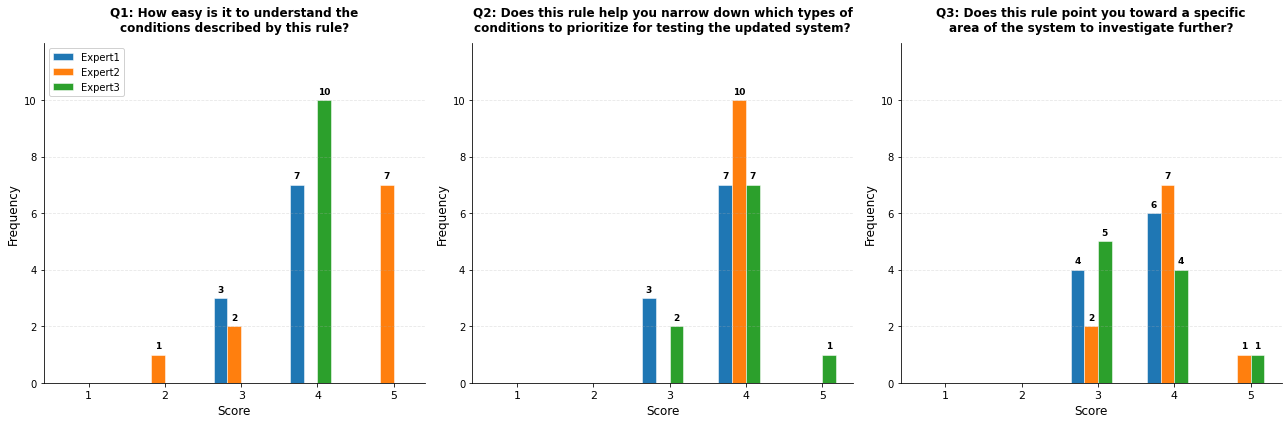

Average score for Q1: 4.00
Average score for Q2: 3.87
Average score for Q3: 3.70


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (q_name, q_data) in enumerate(questions.items()):
    ax = axes[idx]
    x = np.arange(len(values))
    width = 0.18

    for ei, expert in enumerate(experts):
        counts = [q_data[expert].count(v) for v in values]
        bars = ax.bar(x + ei * width, counts, width, label=expert, edgecolor="white", linewidth=0.5)
        for bar, c in zip(bars, counts):
            if c > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                        str(c), ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_title(q_name, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(values, fontsize=11)
    ax.set_ylim(0, 12)
    ax.set_yticks(range(0, 12, 2))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

axes[0].legend(loc="upper left", fontsize=10, framealpha=0.9)
# fig.suptitle("Score Distribution by Expert per Question", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()

plt.show()
fig.savefig(BASE / "expert_assessment_3.pdf")
fig.savefig(BASE / "expert_assessment_3.png", dpi=600)

print(f"Average score for Q1: {np.mean([np.mean(v) for v in q1.values()]):.2f}")
print(f"Average score for Q2: {np.mean([np.mean(v) for v in q2.values()]):.2f}")
print(f"Average score for Q3: {np.mean([np.mean(v) for v in q3.values()]):.2f}")

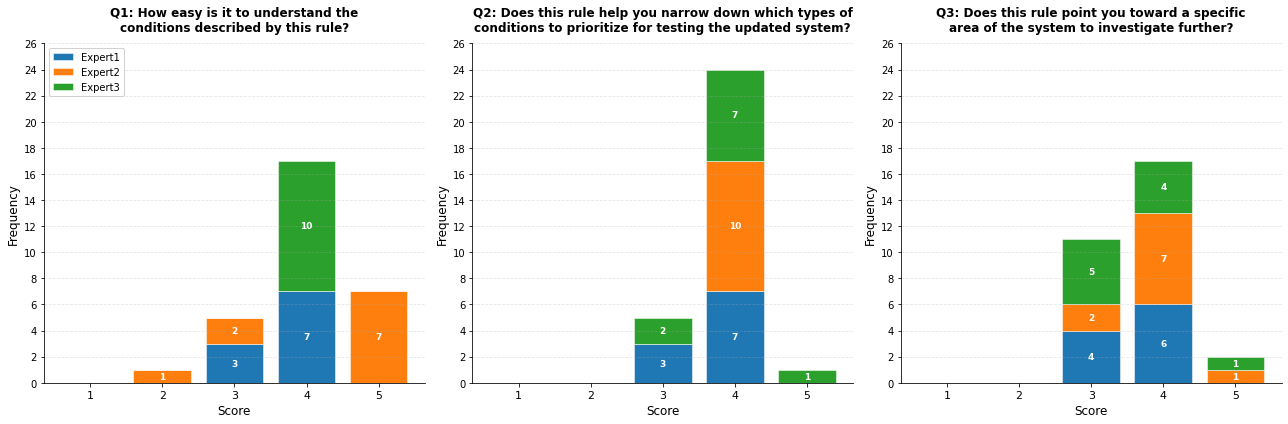

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (q_name, q_data) in enumerate(questions.items()):
    ax = axes[idx]
    x = np.arange(len(values))

    bottom = np.zeros(len(values))  # stacking baseline

    for expert in experts:
        counts = np.array([q_data[expert].count(v) for v in values])

        bars = ax.bar(
            x,
            counts,
            bottom=bottom,
            label=expert,
            edgecolor="white",
            linewidth=0.5
        )

        # annotate each segment
        for i, (bar, c) in enumerate(zip(bars, counts)):
            if c > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bottom[i] + c/2,   # center inside stack
                    str(c),
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white"
                )

        bottom += counts  # update stacking

    ax.set_title(q_name, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(values, fontsize=11)
    ax.set_ylim(0, 25)
    ax.set_yticks(range(0, 28, 2))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

axes[0].legend(loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

fig.savefig(BASE / "expert_assessment_stacked_3.pdf")
fig.savefig(BASE / "expert_assessment_stacked_3.png", dpi=600)

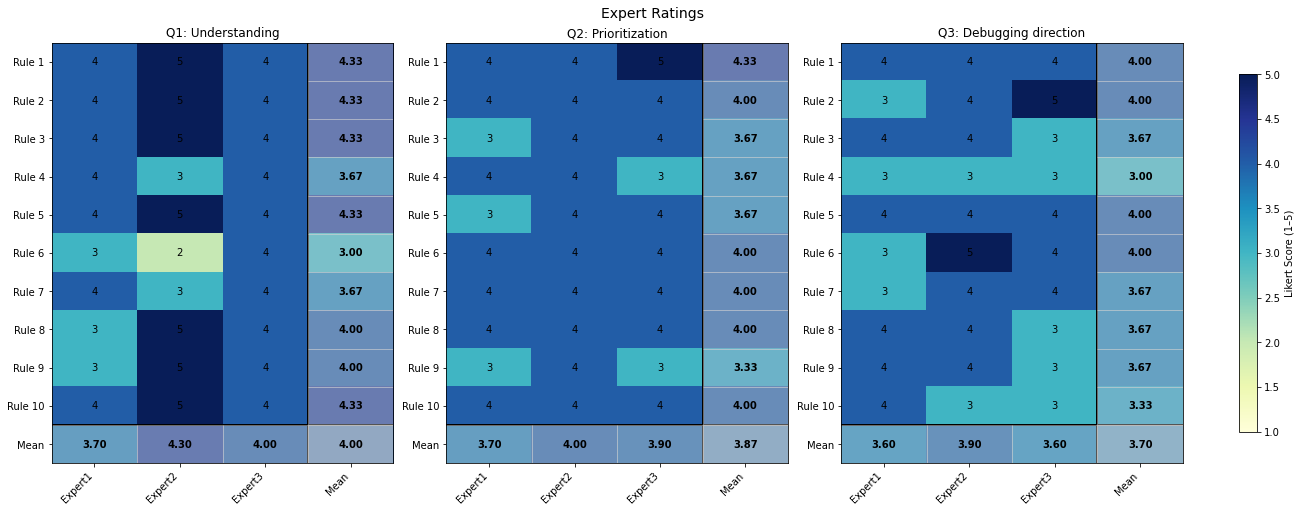

In [9]:
from matplotlib import pyplot as plt
import numpy as np

def plot_heatmap_with_means(ax, title, qdata, experts, rule_labels):
    data = np.array([qdata[e] for e in experts]).T  # (10,4)

    # Means
    row_means = data.mean(axis=1, keepdims=True)
    col_means = data.mean(axis=0, keepdims=True)
    overall_mean = data.mean()

    top = np.hstack([data, row_means])
    bottom = np.hstack([col_means, [[overall_mean]]])
    full = np.vstack([top, bottom])

    x_labels = experts + ["Mean"]
    y_labels = rule_labels + ["Mean"]

    im = ax.imshow(full, cmap="YlGnBu", vmin=1, vmax=5, aspect="auto")

    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels)

    # === Draw separator lines ===
    ax.axhline(len(rule_labels)-0.5, color="black", linewidth=2)
    ax.axvline(len(experts)-0.5, color="black", linewidth=2)

    # === Annotate cells ===
    for i in range(full.shape[0]):
        for j in range(full.shape[1]):
            val = full[i, j]

            is_mean_cell = (i == full.shape[0]-1) or (j == full.shape[1]-1)

            if is_mean_cell:
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="black"
                )
            else:
                ax.text(
                    j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=10
                )

    # === Highlight mean row/column with overlay ===
    # (semi-transparent gray layer)
    for j in range(full.shape[1]):
        ax.add_patch(plt.Rectangle(
            (j-0.5, len(rule_labels)-0.5),
            1, 1,
            fill=True, color="lightgray", alpha=0.4, zorder=2
        ))

    for i in range(full.shape[0]):
        ax.add_patch(plt.Rectangle(
            (len(experts)-0.5, i-0.5),
            1, 1,
            fill=True, color="lightgray", alpha=0.4, zorder=2
        ))

    return im

questions = {
    "Q1: Understanding": q1,
    "Q2: Prioritization": q2,
    "Q3: Debugging direction": q3,
}

rule_labels = [f"Rule {i}" for i in range(1, 11)]

# ===================== PLOT =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

for ax, (title, qdata) in zip(axes, questions.items()):
    im = plot_heatmap_with_means(ax, title, qdata, experts, rule_labels)

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Likert Score (1–5)")

fig.suptitle("Expert Ratings", fontsize=14)

fig.savefig(BASE / "heatmap_3.pdf")
fig.savefig(BASE / "heatmap_3.png", dpi=600)

plt.show()